<a href="https://colab.research.google.com/github/asif-ethmoid/Wind-Power-potential-in-Cox-sBazar-/blob/main/Cox'sBazar_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/research data/CoxsBazar.xlsx')
df.shape

(10044, 6)

In [ ]:
df.size

60264

In [ ]:
df.ndim

2

In [ ]:
df.head(20)

,Day,Month,Temparature,Humidity,Pressure,Windspeed
0,1,1,27.0,75.0,1017.6,2.0
1,1,2,28.2,68.0,1012.6,4.7
2,1,3,30.5,62.0,1013.6,5.0
3,1,4,28.2,89.0,1006.6,3.0
4,1,5,33.5,79.0,1003.8,5.7
5,1,6,32.6,82.0,1005.6,5.0
6,1,7,30.4,90.0,1003.6,10.2
7,1,8,33.0,83.0,999.0,7.2
8,1,9,32.0,82.0,1007.9,4.0
9,1,10,34.2,85.0,1006.2,5.0


In [ ]:
df.tail(20)

,Day,Month,Temparature,Humidity,Pressure,Windspeed
10024,31,5,33.2,78.0,NaN,5.3
10025,31,6,NaN,NaN,NaN,NaN
10026,31,7,31.0,93.0,NaN,3.8
10027,31,8,32.5,82.0,NaN,3.0
10028,31,9,NaN,NaN,NaN,NaN
10029,31,10,34.2,73.0,NaN,6.0
10030,31,11,NaN,NaN,NaN,NaN
10031,31,12,29.0,74.0,NaN,5.4
10032,31,1,25.2,68.0,NaN,2.0
10033,31,2,NaN,NaN,NaN,NaN


In [ ]:
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')

# Calculate month-wise average wind speed
monthly_avg_windspeed = df.groupby('Month')['Windspeed'].mean().reset_index()

# Rename columns for clarity
monthly_avg_windspeed.columns = ['Month', 'Avg_Windspeed']

print(monthly_avg_windspeed)

    Month  Avg_Windspeed
0       1       4.039427
1       2       4.468966
2       3       4.853644
3       4       5.020385
4       5       5.063896
5       6       5.301797
6       7       5.183995
7       8       4.961166
8       9       4.218205
9      10       3.713896
10     11       3.306410
11     12       3.358685


DATA TYPE COLUME NAME

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10044 entries, 0 to 10043
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Day          10044 non-null  int64  
 1   Month        10044 non-null  int64  
 2   Temparature  9783 non-null   float64
 3   Humidity     9740 non-null   float64
 4   Pressure     9132 non-null   float64
 5   Windspeed    9606 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 470.9 KB


In [ ]:
df['Windspeed'] = pd.to_numeric(df['Windspeed'], errors='coerce')

# Calculate statistics
median_windspeed = df['Windspeed'].median()
max_windspeed = df['Windspeed'].max()
min_windspeed = df['Windspeed'].min()
std_windspeed = df['Windspeed'].std()

# Print results
print(f"Median Windspeed: {median_windspeed}")
print(f"Maximum Windspeed: {max_windspeed}")
print(f"Minimum Windspeed: {min_windspeed}")
print(f"Standard Deviation of Windspeed: {std_windspeed}")

Median Windspeed: 4.2
Maximum Windspeed: 38.7
Minimum Windspeed: 0.0
Standard Deviation of Windspeed: 2.4705832449732177


In [ ]:
print((df == 0).sum())

Day              0
Month            0
Temparature      0
Humidity         0
Pressure         0
Windspeed      762
dtype: int64


In [ ]:
df.describe()

,Day,Month,Temparature,Humidity,Pressure,Windspeed
count,10044.000000,10044.000000,9783.000000,9740.000000,9132.000000,9606.000000
mean,16.000000,6.500000,31.137443,79.656776,1008.028811,4.457308
std,8.944717,3.452224,2.562079,8.980873,4.709520,2.470583
min,1.000000,1.000000,19.700000,42.000000,991.100000,0.000000
25%,8.000000,3.750000,29.500000,74.000000,1004.500000,3.000000
50%,16.000000,6.500000,31.600000,80.000000,1008.600000,4.200000
75%,24.000000,9.250000,33.000000,86.000000,1011.800000,5.800000
max,31.000000,12.000000,39.500000,100.000000,1019.100000,38.700000


In [ ]:
df.dtypes

,0
Day,int64
Month,int64
Temparature,float64
Humidity,float64
Pressure,float64
Windspeed,float64


#Is There any NULL value

In [ ]:
df.isnull().sum().sum()


1915

In [ ]:
df.tail(24)

,Day,Month,Temparature,Humidity,Pressure,Windspeed
10020,31,1,26.0,67.0,NaN,5.0
10021,31,2,NaN,NaN,NaN,NaN
10022,31,3,31.4,77.0,NaN,7.7
10023,31,4,NaN,NaN,NaN,NaN
10024,31,5,33.2,78.0,NaN,5.3
10025,31,6,NaN,NaN,NaN,NaN
10026,31,7,31.0,93.0,NaN,3.8
10027,31,8,32.5,82.0,NaN,3.0
10028,31,9,NaN,NaN,NaN,NaN
10029,31,10,34.2,73.0,NaN,6.0


In [ ]:

# Assuming 'df' is your DataFrame and 'z' is a column in the DataFrame
# List of columns to check for outliers
columns = ['Temparature', 'Humidity', 'Pressure', 'Windspeed']

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

# Detect outliers for each column once and create a mask
outliers_mask = pd.DataFrame(False, index=df.index, columns=columns)
for column in columns:
    outliers_mask[column] = detect_outliers_iqr(df, column)

# Fill missing values and calculate group means by 'z' only once for each column
group_means = df.groupby('Month')[columns].transform('mean')

# Fill missing values with group mean
df[columns] = df.groupby('Month')[columns].transform(lambda x: x.fillna(x.mean()))

# Replace outliers with the group's mean value (only where outliers are detected)
for column in columns:
    df.loc[outliers_mask[column], column] = group_means.loc[outliers_mask[column], column]

In [ ]:
print((df == 0).sum())

Day              0
Month            0
Temparature      0
Humidity         0
Pressure         0
Windspeed      762
dtype: int64


In [ ]:
df.head(100)

,Day,Month,Temparature,Humidity,Pressure,Windspeed
0,1,1,27.0,75.0,1017.6,2.0
1,1,2,28.2,68.0,1012.6,4.7
2,1,3,30.5,62.0,1013.6,5.0
3,1,4,28.2,89.0,1006.6,3.0
4,1,5,33.5,79.0,1003.8,5.7
...,...,...,...,...,...,...
95,1,12,29.0,77.0,1014.1,4.0
96,1,1,25.0,90.0,1015.2,6.0
97,1,2,31.2,64.0,1010.5,6.0
98,1,3,30.6,79.0,1010.1,4.0


**Min-Max Normalization**

In [ ]:
scaler = MinMaxScaler()

# Select columns to normalize
cols_to_normalize = ['Day','Month', 'Temparature', 'Humidity', 'Pressure']

# Normalize the selected columns
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

In [ ]:
zero_count = (df == 0).sum().sum()

print(f'Total number of zero values: {zero_count}')

# If you want to see the number of zeros per column
zero_per_column = (df == 0).sum()

print(zero_per_column)

Total number of zero values: 1949
Day            324
Month          837
Temparature      4
Humidity        21
Pressure         1
Windspeed      762
dtype: int64


In [ ]:
df.tail()

,Day,Month,Temparature,Humidity,Pressure,Windspeed
10039,1.0,0.636364,0.722628,0.613636,0.368235,4.961166
10040,1.0,0.727273,0.557145,0.680944,0.472567,4.218205
10041,1.0,0.818182,0.583694,0.610055,0.602205,3.713896
10042,1.0,0.909091,0.500459,0.469376,0.699816,3.306410
10043,1.0,1.000000,0.298880,0.425220,0.769530,3.358685


#After replacinng the value Corelation among the variables

In [ ]:
df.corr()

,Day,Month,Temparature,Humidity,Pressure,Windspeed
Day,1.000000e+00,8.900038e-16,-0.018991,-0.006763,0.001295,0.012552
Month,8.900038e-16,1.000000e+00,0.046560,0.289987,-0.108759,-0.158677
Temparature,-1.899113e-02,4.656022e-02,1.000000,-0.039662,-0.346881,0.058174
Humidity,-6.763356e-03,2.899874e-01,-0.039662,1.000000,-0.608809,0.020754
Pressure,1.295051e-03,-1.087589e-01,-0.346881,-0.608809,1.000000,-0.213692
Windspeed,1.255163e-02,-1.586767e-01,0.058174,0.020754,-0.213692,1.000000


#Scatter plot

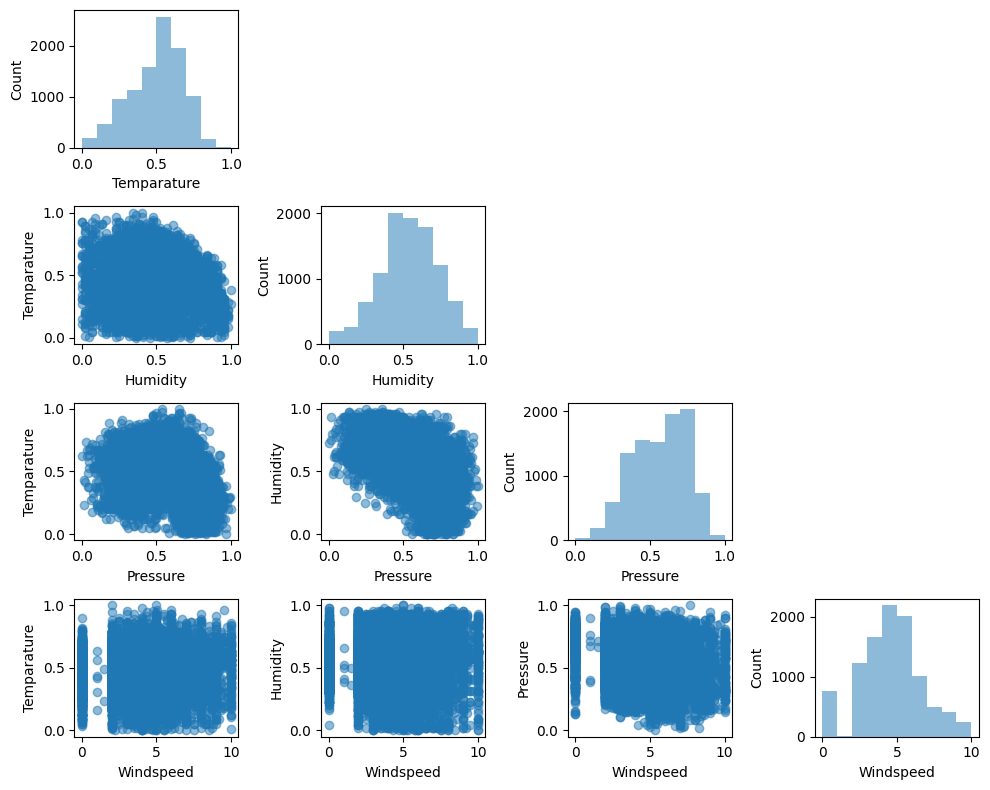

In [ ]:
cols = ["Temparature","Humidity","Pressure","Windspeed"]
scatterplotmatrix(df[cols].values,figsize=(10,8),names=cols,alpha=0.5)
plt.tight_layout()
plt.show()


#HeatMap

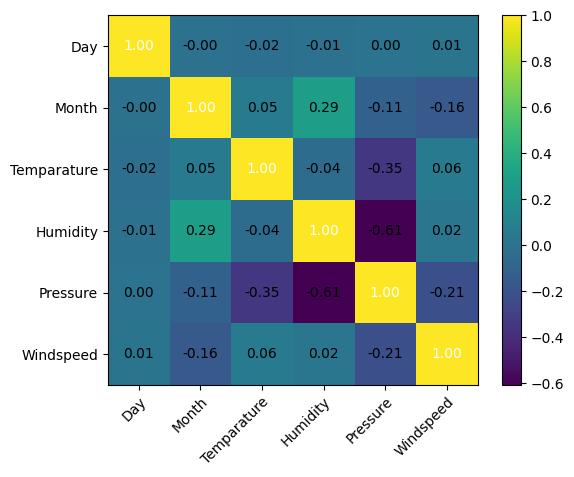

In [ ]:
from mlxtend.plotting import heatmap
cols1 = ["Day","Month","Temparature","Humidity","Pressure","Windspeed"]
cm = np.corrcoef(df[cols1].values.T)
hm = heatmap(cm, row_names=cols1, column_names=cols1)
plt.show()


#Histogram

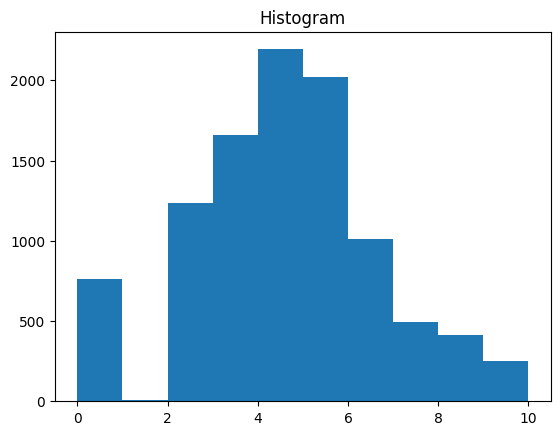

In [ ]:
plt.hist(df['Windspeed'])
plt.title("Histogram")
plt.show()

In [ ]:
X = df.iloc[:,:-1]


Y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=10)

#Linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [ ]:
Y_pred_lr = lr.predict(X_test)

results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred_lr
})
print(results.head(200))

      Actual  Predicted
4113     2.0   3.412153
7828     8.0   5.244336
1101     4.0   3.997197
902      0.0   4.497910
7592     5.3   4.369830
...      ...        ...
1629     5.0   3.769375
3506     3.5   4.193032
2875     3.5   4.655155
265      0.0   4.346010
1760     9.0   4.299499

[200 rows x 2 columns]


#Model Evaluation for Liear Regression

> Add blockquote



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming Y_test and Y_pred_lr are defined
mse = mean_squared_error(Y_test, Y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred_lr)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, Y_pred_lr)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)


MSE: 3.95
RMSE: 1.99
MAE: 1.53
Correlation coefficient between Y_test and y_pred: 0.28574880306022415


#Ridge_regression model

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.85)
ridge.fit(X_train,Y_train)

Ridge(alpha=0.85)

In [ ]:
Y_pred_ridge = ridge.predict(X_test)
results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred_ridge
})
print(results.head(20))

      Actual  Predicted
4113     2.0   3.418334
7828     8.0   5.241407
1101     4.0   3.999890
902      0.0   4.499925
7592     5.3   4.368075
4202     8.0   4.925351
5234     5.5   4.545733
445      5.0   4.044953
755      0.0   3.184496
5151     3.2   4.391809
5523     4.0   4.088826
4133     6.0   4.874648
7045     2.8   3.868510
4712     3.0   4.371681
972      3.0   4.100845
9342     3.0   4.936012
2389     4.0   4.083056
4421     3.7   5.302236
1665     0.0   3.350530
5109     2.0   3.923996


#Model Evaluation for Ridge

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming Y_test and Y_pred_lr are defined
mse = mean_squared_error(Y_test, Y_pred_ridge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred_ridge)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, Y_pred_ridge)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)


MSE: 3.95
RMSE: 1.99
MAE: 1.53
Correlation coefficient between Y_test and y_pred: 0.2857842063832587


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,max_depth=10)
rf.fit(X_train,Y_train)

RandomForestRegressor(max_depth=10)

In [ ]:
Y_pred_rf = rf.predict(X_test)

results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred_rf
})
print(results.head(20))


      Actual  Predicted
4113     2.0   3.551008
7828     8.0   5.662498
1101     4.0   3.380286
902      0.0   4.835860
7592     5.3   3.928151
4202     8.0   5.331571
5234     5.5   4.868327
445      5.0   5.392408
755      0.0   4.230621
5151     3.2   4.291113
5523     4.0   4.492690
4133     6.0   5.347674
7045     2.8   3.479485
4712     3.0   3.595026
972      3.0   3.534025
9342     3.0   5.237432
2389     4.0   4.654110
4421     3.7   5.277726
1665     0.0   3.625156
5109     2.0   3.481003


#Model Evaluation for Random forest

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming Y_test and Y_pred_rf are already defined
mse = mean_squared_error(Y_test, Y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred_rf)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, Y_pred_rf)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)


MSE: 3.73
RMSE: 1.93
MAE: 1.49
Correlation coefficient between Y_test and y_pred: 0.36763639500301665


#Cat Boost Regression Mdoel

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

In [ ]:
Cat_Boost = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0)
Cat_Boost.fit(X_train, Y_train)


In [ ]:
y_pred_catB = Cat_Boost.predict(X_test)

results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': y_pred_catB
})
print(results.head(20))

      Actual  Predicted
4113     2.0   3.524563
7828     8.0   6.624458
1101     4.0   3.558777
902      0.0   4.179815
7592     5.3   3.431643
4202     8.0   5.076720
5234     5.5   4.655083
445      5.0   5.329491
755      0.0   4.615260
5151     3.2   4.317346
5523     4.0   4.720882
4133     6.0   5.726308
7045     2.8   3.599176
4712     3.0   3.256907
972      3.0   2.980533
9342     3.0   5.353107
2389     4.0   4.657277
4421     3.7   5.456691
1665     0.0   3.756107
5109     2.0   3.381887


#Model Evaluation of CatBoost Regression Model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming Y_test and y_pred_catB are already defined
mse = mean_squared_error(Y_test, y_pred_catB)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred_catB)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, y_pred_catB)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)

MSE: 3.88
RMSE: 1.97
MAE: 1.53
Correlation coefficient between Y_test and y_pred: 0.34254138320576677


#Adaboost

In [ ]:

class AdaBoostRegressor:
    def __init__(self, n_estimators=50, learning_rate=1.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.model_weights = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        # Initialize weights uniformly
        sample_weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            # Fit a weak learner (DecisionTreeRegressor with max_depth=1, which is a decision stump)
            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X, y, sample_weight=sample_weights)

            # Make predictions
            y_pred = stump.predict(X)

            # Compute errors and weighted error
            errors = np.abs(y - y_pred)
            weighted_error = np.dot(sample_weights, errors) / np.sum(sample_weights)

            # Clip the weighted error to avoid invalid values in log
            weighted_error = np.clip(weighted_error, 1e-10, 1 - 1e-10)

            # Compute model weight (alpha)
            alpha = self.learning_rate * np.log((1 - weighted_error) / (weighted_error + 1e-10))

            # Update sample weights
            sample_weights *= np.exp(alpha * errors)
            sample_weights /= np.sum(sample_weights)  # Normalize the sample weights

            # Save the model and its weight
            self.models.append(stump)
            self.model_weights.append(alpha)

    def predict(self, X):
        # Weighted sum of predictions from all the models
        model_preds = np.array([model.predict(X) for model in self.models])
        y_pred = np.dot(self.model_weights, model_preds)
        return y_pred / np.sum(self.model_weights)

In [ ]:
X, y = make_regression(n_samples=500, n_features=1, noise=20, random_state=42)
adaboost_reg = AdaBoostRegressor(n_estimators=50, learning_rate=0.1)
adaboost_reg.fit(X_train, Y_train)

In [ ]:
y_pred = adaboost_reg.predict(X_test)
comparison_df = pd.DataFrame({
    'Actual Value': Y_test,
    'Predicted Value': y_pred
})

# Print the comparison
print(comparison_df)

      Actual Value  Predicted Value
4113      2.000000         3.546418
7828      8.000000         4.695939
1101      4.000000         3.546418
902       0.000000         4.695939
7592      5.300000         3.546418
...            ...              ...
3627      5.000000         4.695939
5503      4.961166         4.695939
8154      4.700000         4.695939
7369      4.500000         4.695939
7855      5.000000         4.695939

[2009 rows x 2 columns]


#EVALUATION of Adaboost

In [ ]:


# Assuming Y_test and y_pred are already defined
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, y_pred)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)

MSE: 4.05
RMSE: 2.01
MAE: 1.56
Correlation coefficient between Y_test and y_pred: 0.24377272119924506


#Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
Decision = DecisionTreeRegressor()

# Fit the model on the training data
Decision.fit(X_train, Y_train)

# Make predictions on the test data
y_pred = Decision.predict(X_test)

In [ ]:


results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': y_pred
})
print(results.head(20))

      Actual  Predicted
4113     2.0        6.0
7828     8.0        7.7
1101     4.0        3.0
902      0.0        5.0
7592     5.3        7.0
4202     8.0        5.2
5234     5.5        3.0
445      5.0        7.5
755      0.0        5.7
5151     3.2        0.0
5523     4.0        6.0
4133     6.0        4.0
7045     2.8        7.0
4712     3.0        5.0
972      3.0        2.0
9342     3.0        3.8
2389     4.0        2.0
4421     3.7        6.0
1665     0.0        5.0
5109     2.0        0.0


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming Y_test and y_pred are already defined
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
correlation = np.corrcoef(Y_test, y_pred)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)

MSE: 7.97
RMSE: 2.82
MAE: 2.18
Correlation coefficient between Y_test and y_pred: 0.1542355462197456


 # XBoost

In [ ]:
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Loss function for regression
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.01,            # Step size shrinkage
    max_depth=5,                  # Maximum depth of trees
    random_state=42
)


In [ ]:
# Train the model
xgboost_model.fit(X_train, Y_train)

# Predict on test data
y_pred = xgboost_model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': y_pred
})
print(results.head(20))

      Actual  Predicted
4113     2.0   3.733716
7828     8.0   5.022191
1101     4.0   3.996615
902      0.0   4.644094
7592     5.3   4.161260
4202     8.0   4.873813
5234     5.5   4.627851
445      5.0   4.888515
755      0.0   4.048546
5151     3.2   4.495110
5523     4.0   4.228543
4133     6.0   4.913008
7045     2.8   3.914740
4712     3.0   4.088098
972      3.0   3.964304
9342     3.0   5.009653
2389     4.0   4.839823
4421     3.7   4.906568
1665     0.0   3.737296
5109     2.0   4.013749


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assuming Y_test and y_pred are already defined
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

# Print MSE, RMSE, and MAE
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Calculate the correlation coefficient between the true values and predicted values
correlation = np.corrcoef(Y_test, y_pred)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)


MSE: 3.87
RMSE: 1.97
MAE: 1.51
Correlation coefficient between Y_test and y_pred: 0.33443293945852276


# MLP

In [ ]:
caler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the MLP regressor
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, Y_train)



MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)

In [ ]:
# Assuming Y_test and y_pred are already defined
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

# Print MSE, RMSE, and MAE
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Calculate the correlation coefficient between the true values and predicted values
correlation = np.corrcoef(Y_test, y_pred)[0, 1]

print("Correlation coefficient between Y_test and y_pred:", correlation)

MSE: 3.87
RMSE: 1.97
MAE: 1.51
Correlation coefficient between Y_test and y_pred: 0.33443293945852276


# Deep neural network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the DNN model for regression
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # First hidden layer
    Dropout(0.2),  # Prevent overfitting
    Dense(64, activation='relu'),  # Second hidden layer
    Dropout(0.2),
    Dense(32, activation='relu'),  # Third hidden layer
    Dense(1)  # Output layer for regression
])

# Compile the model with an optimizer, loss, and evaluation metric
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adaptive learning rate
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as an additional metric
)

# Train the model
history = model.fit(
    X_train_scaled, Y_train,
    validation_data=(X_test_scaled, Y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model
loss, mae = model.evaluate(X_test_scaled, Y_test, verbose=0)

# Predict values
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)

# Calculate the Pearson correlation coefficient
correlation = np.corrcoef(Y_test, y_pred.flatten())[0, 1]

# Print evaluation metrics and correlation
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Correlation between Actual and Predicted: {correlation:.2f}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 8.3381 - mae: 2.2771 - val_loss: 4.1492 - val_mae: 1.5813
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4.5354 - mae: 1.6522 - val_loss: 4.0177 - val_mae: 1.5585
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.4135 - mae: 1.6324 - val_loss: 3.9982 - val_mae: 1.5584
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.2185 - mae: 1.6099 - val_loss: 3.8652 - val_mae: 1.5242
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1993 - mae: 1.5949 - val_loss: 4.0362 - val_mae: 1.5521
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2003 - mae: 1.5922 - val_loss: 3.8631 - val_mae: 1.5290
Epoch 7/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1668 - mae: 1.5809 - val_loss: 4.0476 - val_mae: 1.5619
Epoch 8/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1709 - mae: 1.5688 - val_loss: 3.8414 - val_mae: 1.5224
Epoch 9/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

# Gaussian Hidden Markov Model

In [ ]:
!pip install hmmlearn
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Combine features and target for HMM (HMM needs sequence data)
train_data = np.hstack([X_train_scaled, Y_train.values.reshape(-1, 1)])


# Define and train the Gaussian HMM
n_components = 5  # Number of hidden states
model = GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=100, random_state=42)
model.fit(train_data)

# Generate predictions (predict most likely hidden states, then map to observations)
train_states = model.predict(train_data)
test_data = np.hstack([X_test_scaled, Y_test.values.reshape(-1, 1)])
test_states = model.predict(test_data)

# Predict Windspeed using the mean of each hidden state's observations
predicted_windspeed = np.array([model.means_[state, -1] for state in test_states])

# Calculate evaluation metrics
mse = mean_squared_error(Y_test, predicted_windspeed)
mae = mean_absolute_error(Y_test, predicted_windspeed)
rmse = np.sqrt(mse)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Correlation between actual and predicted
correlation = np.corrcoef(Y_test, predicted_windspeed)[0, 1]
print(f"Correlation between Actual and Predicted: {correlation:.2f}")

# LSTM

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data to 3D for LSTM [samples, timesteps, features]
# Assume each sample has 1 timestep since data isn't time-series
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Define the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Single output for regression
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as an additional metric
)

# Train the model
history = model.fit(
    X_train_reshaped, Y_train,
    validation_data=(X_test_reshaped, Y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Predict values
y_pred = model.predict(X_test_reshaped)

# Calculate evaluation metrics
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
correlation = np.corrcoef(Y_test, y_pred.flatten())[0, 1]

# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Correlation between Actual and Predicted: {correlation:.2f}")

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


252/252 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 15.6285 - mae: 3.3467 - val_loss: 4.1903 - val_mae: 1.5890
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 4.8151 - mae: 1.7224 - val_loss: 4.0342 - val_mae: 1.5598
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.4004 - mae: 1.6392 - val_loss: 3.9385 - val_mae: 1.5391
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.6073 - mae: 1.6802 - val_loss: 3.9190 - val_mae: 1.5331
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.5183 - mae: 1.6570 - val_loss: 3.8913 - val_mae: 1.5285
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.3936 - mae: 1.6356 - val_loss: 3.8984 - val_mae: 1.5299
Epoch 7/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3931 - mae: 1.6425 - val_loss: 3.8859 - val_mae: 1.5268
Epoch 8/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2572 - mae: 1.6012 - val_loss: 3.8516 - val_mae: 1.5202
Epoch 9/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.23